<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Transfer_Learning_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

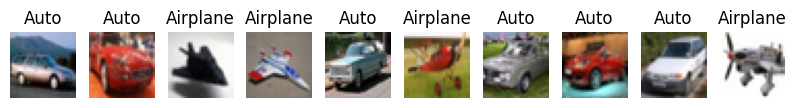

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

# 1. CARGAR CIFAR-10 (Dataset CIFAR-10)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

mask = np.where((y_train == 0) | (y_train == 1))[0]
x = x_train[mask]
y = y_train[mask]

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x[i])
    plt.axis('off')
    plt.title("Airplane" if y[i]==0 else "Auto")
plt.show()

In [ ]:
mask_train = np.where((y_train == 0) | (y_train == 1))[0]
mask_test = np.where((y_test == 0) | (y_test == 1))[0]

x_train = x_train[mask_train]
y_train = y_train[mask_train]
x_test = x_test[mask_test]
y_test = y_test[mask_test]

# Normalizar
x_train = x_train / 255.0
x_test = x_test / 255.0

IMG_SIZE = (160, 160)

# Redimensionar imágenes a 160x160 para MobileNetV2
x_train = tf.image.resize(x_train, IMG_SIZE)
x_test = tf.image.resize(x_test, IMG_SIZE)


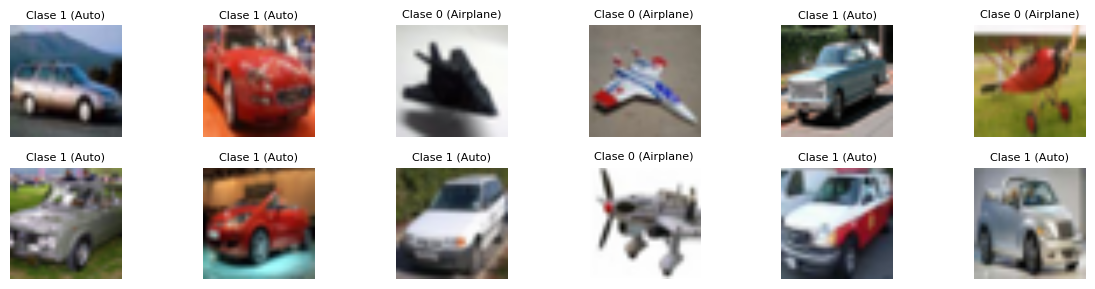

In [ ]:
def mostrar_ejemplos(x, y, num=12):
    plt.figure(figsize=(12, 3))

    for i in range(num):
        plt.subplot(2, num//2, i+1)
        img = x[i].numpy()   # Convertir tensor a array para graficar
        plt.imshow(img)
        plt.axis("off")

        etiqueta = "Clase 0 (Airplane)" if y[i] == 0 else "Clase 1 (Auto)"
        plt.title(etiqueta, fontsize=8)

    plt.tight_layout()
    plt.show()

mostrar_ejemplos(x_train, y_train)

In [ ]:
# 2. CARGAR EL MODELO PRE-ENTRENADO

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Congelamos las capas

In [ ]:
# 3. CONSTRUIR LA CABEZA DEL MODELO

inputs = Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

In [ ]:
# 4. ENTRENAR

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=5,
    batch_size=32
)


63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 607ms/step


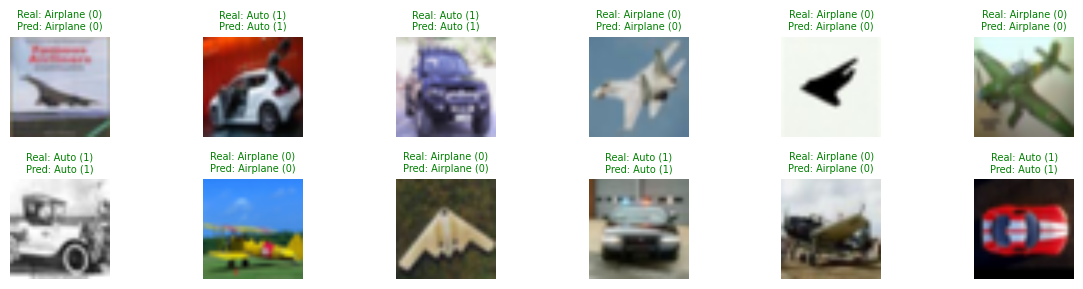

In [ ]:
# Obtener predicciones del modelo (valores entre 0 y 1)
preds = model.predict(x_test)

# Convertir a clases (0 o 1)
pred_labels = (preds > 0.5).astype(int).flatten()

# Función para graficar
def mostrar_predicciones(x, y_true, y_pred, num=12):
    plt.figure(figsize=(12, 3))

    for i in range(num):
        plt.subplot(2, num//2, i+1)
        img = x[i].numpy()  # convertir tensor a array
        plt.imshow(img)
        plt.axis("off")

        real = "Airplane (0)" if y_true[i] == 0 else "Auto (1)"
        pred = "Airplane (0)" if y_pred[i] == 0 else "Auto (1)"

        color = "green" if y_true[i] == y_pred[i] else "red"
        plt.title(f"Real: {real}\nPred: {pred}", fontsize=7, color=color)

    plt.tight_layout()
    plt.show()

mostrar_predicciones(x_test, y_test, pred_labels)

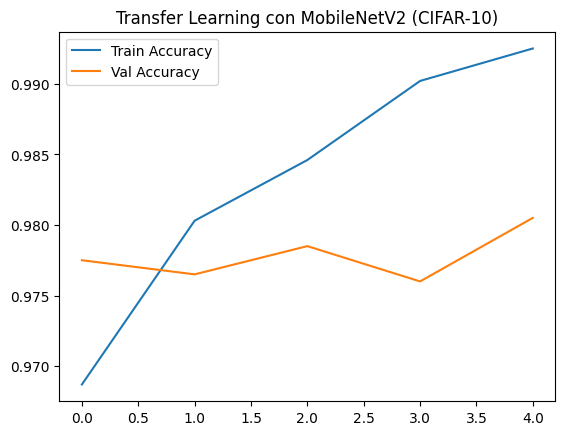

In [ ]:
# GRAFICAR RESULTADOS

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Transfer Learning con MobileNetV2 (CIFAR-10)")
plt.show()

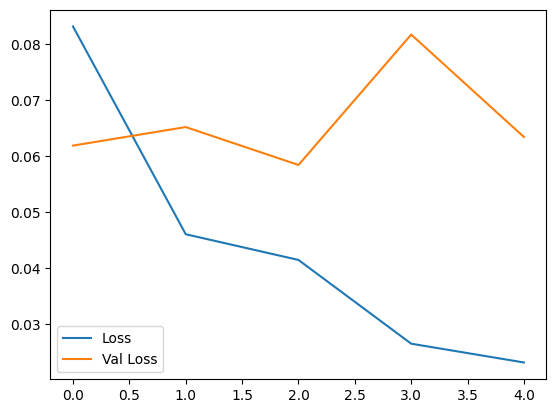

In [ ]:
plt.plot(history.history["loss"], label = "Loss")
plt.plot(history.history["val_loss"], label = "Val Loss")
plt.legend()

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 687ms/step


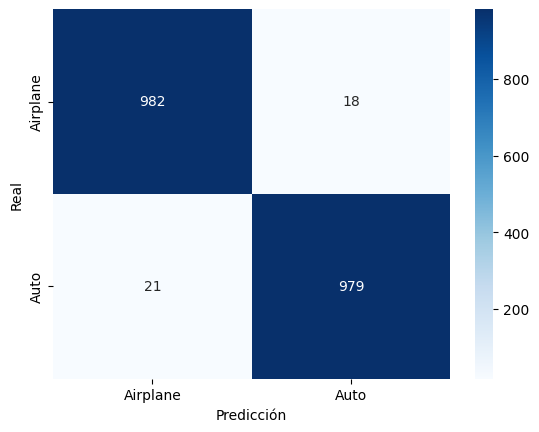

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds = (model.predict(x_test) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Airplane","Auto"],
            yticklabels=["Airplane","Auto"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()
